In [1]:
# from fink_utils.sso.spins import func_hg1g2, cos_aspect_angle
# from fink_utils.sso.periods import estimate_synodic_period 

import numpy as np
import matplotlib.pyplot as plt


# import seaborn as sns
# sns.set_context("poster")

# Illustration of ss($\alpha$, $\delta$) function

/tmp/ipykernel_20870/3450241318.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


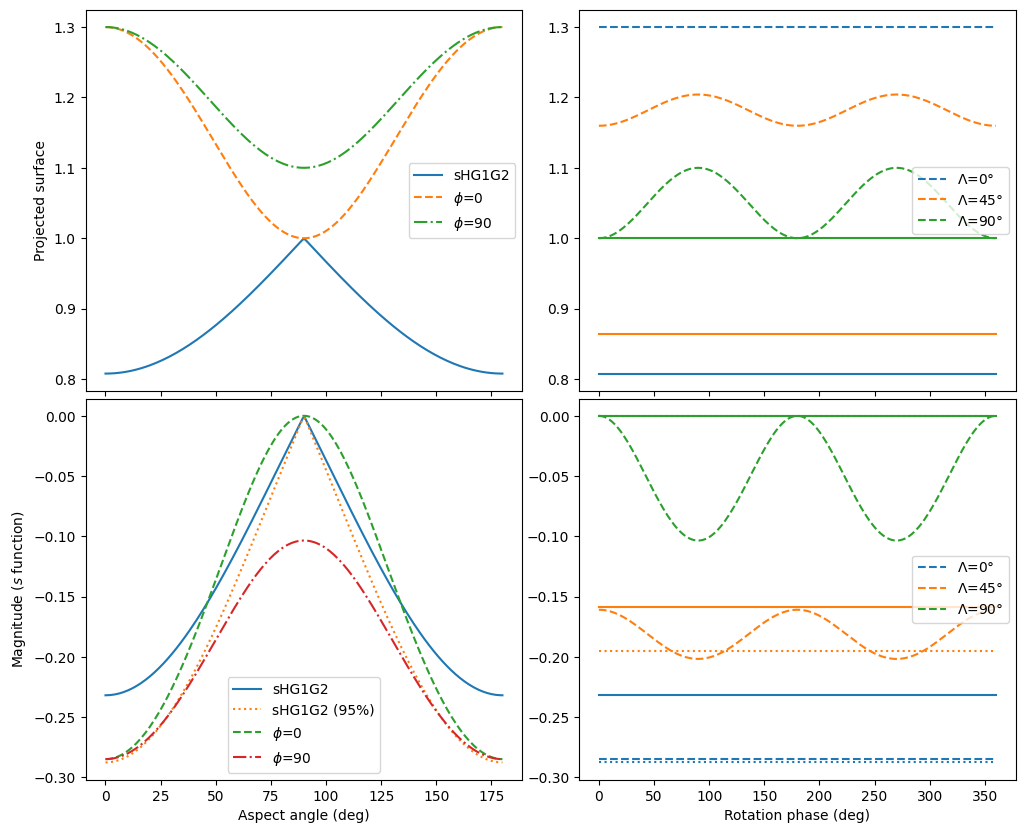

In [2]:
# Test values
a_b = 1.1
a_c = 1.3

# Derive the R parameter
a = 1
b = a / a_b
c = a / a_c
R = c * (a + b) / (2 * a * b)

# Change of aspect
nbd = 180
aspect = np.linspace(0, np.pi, nbd)

cos_aspect = np.cos(aspect)
cos_aspect_2 = cos_aspect**2
sin_aspect_2 = 1 - cos_aspect_2
rot_phase = 0
rot_phase_b = np.pi / 2

factor = 0.95

func1 = 1 - (1 - R) * np.abs(cos_aspect)
func1_b = 1 - (1 - R * factor) * np.abs(cos_aspect)

func2 = np.sqrt(
    sin_aspect_2 * (np.cos(rot_phase) ** 2 + (a_b**2) * np.sin(rot_phase) ** 2)
    + cos_aspect_2 * a_c**2
)

func2_b = np.sqrt(
    sin_aspect_2 * (np.cos(rot_phase_b) ** 2 + (a_b**2) * np.sin(rot_phase_b) ** 2)
    + cos_aspect_2 * a_c**2
)


fig, ax = plt.subplots(
    2, 2, figsize=(12, 10), gridspec_kw={"wspace": 0.13, "hspace": 0.02}
)

ax[0, 0].plot(np.degrees(aspect), func1, label="sHG1G2")
ax[0, 0].plot(np.degrees(aspect), func2, ls="--", label="$\\phi$=0")
ax[0, 0].plot(np.degrees(aspect), func2_b, ls="-.", label="$\\phi$=90")

ax[1, 0].plot(np.degrees(aspect), 2.5 * np.log10(func1), label="sHG1G2")
ax[1, 0].plot(
    np.degrees(aspect), 2.5 * np.log10(func1_b), ls="dotted", label="sHG1G2 (95%)"
)
ax[1, 0].plot(np.degrees(aspect), -2.5 * np.log10(func2), ls="--", label="$\\phi$=0")
ax[1, 0].plot(np.degrees(aspect), -2.5 * np.log10(func2_b), ls="-.", label="$\\phi$=90")


rot_phase = np.linspace(0, 2 * np.pi, 180)

for i, aspect in enumerate([0, np.pi / 4, np.pi / 2]):
    cos_aspect = np.cos(aspect)
    cos_aspect_2 = cos_aspect**2
    sin_aspect_2 = 1 - cos_aspect_2

    func1 = np.full(nbd, 1 - (1 - R) * np.abs(cos_aspect))
    func1_b = np.full(nbd, 1 - (1 - R * factor) * np.abs(cos_aspect))
    func2 = np.sqrt(
        sin_aspect_2 * (np.cos(rot_phase) ** 2 + (a_b**2) * np.sin(rot_phase) ** 2)
        + cos_aspect_2 * a_c**2
    )
    ax[0, 1].plot(np.degrees(rot_phase), func1, color=f"C{i}")
    ax[0, 1].plot(
        np.degrees(rot_phase),
        func2,
        color=f"C{i}",
        ls="--",
        label=f"$\\Lambda$={np.degrees(aspect):.0f}°",
    )

    ax[1, 1].plot(np.degrees(rot_phase), 2.5 * np.log10(func1), color=f"C{i}")
    ax[1, 1].plot(
        np.degrees(rot_phase), 2.5 * np.log10(func1_b), color=f"C{i}", ls="dotted"
    )
    ax[1, 1].plot(
        np.degrees(rot_phase),
        -2.5 * np.log10(func2),
        color=f"C{i}",
        ls="--",
        label=f"$\\Lambda$={np.degrees(aspect):.0f}°",
    )


ax[1, 1].set_xlabel("Rotation phase (deg)")
ax[1, 0].set_xlabel("Aspect angle (deg)")
ax[0, 0].set_ylabel("Projected surface")
ax[1, 0].set_ylabel("Magnitude ($s$ function)")

for a in ax.flatten():
    a.legend()

fig.tight_layout()
fig.savefig("ssHG1G2.png")

The new definition of $s(\alpha,\delta)$ leads to similar correction against aspect angle (bottom left figure). However

- it allows for rotation 
- there is a systematic offset in magnitude toward ``pole-on'' geometry, solved if R is taken as 0.95*R... why?

# Illustration of ss($\alpha$, $\delta$) function for article

In [3]:
import sys
sys.path.append('..')
import figure_setup as fs

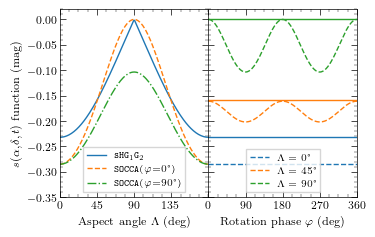

In [5]:
# --------------------------------------------------------------------------------
# Test values
a_b = 1.1
a_c = 1.3

# Derive the R parameter
a = 1
b = a / a_b
c = a / a_c
R = c * (a + b) / (2 * a * b)

# Change of aspect
nbd = 180
aspect = np.linspace(0, np.pi, nbd)

cos_aspect = np.cos(aspect)
cos_aspect_2 = cos_aspect**2
sin_aspect_2 = 1 - cos_aspect_2
rot_phase = 0
rot_phase_b = np.pi / 2

factor = 0.95

func1 = 1 - (1 - R) * np.abs(cos_aspect)
func1_b = 1 - (1 - R * factor) * np.abs(cos_aspect)

func2 = np.sqrt(
    sin_aspect_2 * (np.cos(rot_phase) ** 2 + (a_b**2) * np.sin(rot_phase) ** 2)
    + cos_aspect_2 * a_c**2
)


# --------------------------------------------------------------------------------
# Figure definition
fig, ax = plt.subplots(
    1,
    2,
    figsize=fs.figsize(0.5),
    sharey=True,
    gridspec_kw={
        "wspace": 0.0,
        "bottom": 0.15,
        "top": 0.99,
        "right": 0.97,
        "left": 0.15,
    },
)

# --------------------------------------------------------------------------------
# VS aspect angle
ax[0].plot(
    np.degrees(aspect), 2.5 * np.log10(func1), label=r"$\texttt{sHG}_1\texttt{G}_2$"
)
ax[0].plot(
    np.degrees(aspect),
    -2.5 * np.log10(func2),
    ls="--",
    label="$\\texttt{SOCCA} (\\varphi$=0°)",
)
ax[0].plot(
    np.degrees(aspect),
    -2.5 * np.log10(func2_b),
    ls="-.",
    label="$\\texttt{SOCCA} (\\varphi$=90°)",
)

# --------------------------------------------------------------------------------
# VS rotation phase
rot_phase = np.linspace(0, 2 * np.pi, 180)
for i, aspect in enumerate([0, np.pi / 4, np.pi / 2]):
    cos_aspect = np.cos(aspect)
    cos_aspect_2 = cos_aspect**2
    sin_aspect_2 = 1 - cos_aspect_2

    func1 = np.full(nbd, 1 - (1 - R) * np.abs(cos_aspect))
    func2 = np.sqrt(
        sin_aspect_2 * (np.cos(rot_phase) ** 2 + (a_b**2) * np.sin(rot_phase) ** 2)
        + cos_aspect_2 * a_c**2
    )

    ax[1].plot(np.degrees(rot_phase), 2.5 * np.log10(func1), color=f"C{i}")

    ax[1].plot(
        np.degrees(rot_phase),
        -2.5 * np.log10(func2),
        color=f"C{i}",
        ls="--",
        label=f"$\\Lambda={np.degrees(aspect):.0f}$°",
    )

# --------------------------------------------------------------------------------
# Axes
ax[0].set_xlabel("Aspect angle $\\Lambda$ (deg)")
ax[1].set_xlabel("Rotation phase $\\varphi$ (deg)")
ax[0].set_ylabel("$s(\\alpha,\\delta,t$) function (mag)")

ax[0].set_xticks([0, 45, 90, 135])
ax[1].set_xticks([0, 90, 180, 270, 360])

ax[0].set_ylim(-0.35, 0.02)
ax[0].legend(loc="lower center", fontsize="x-small")
ax[1].legend(
    loc="lower center",
    fontsize="x-small",
)

fig.savefig("socca_model.pgf")
fig.savefig("socca_model.png")